In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

from decimal import Decimal

import mesa_helper as mh
import os
import shutil
import copy
import time
import warnings

from scipy import ndimage, interpolate, optimize
from scipy.integrate import quad
import pickle

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# As far as I understand it, the proper way to use the CD21 tables for arbitrary H/He mixtures is to take their
# "effective H" table and combine it with the CMS19 He table using the additive volume law. 
# Let's see if I can reproduce their Y=0.245 table this way.

In [3]:
# note that we're working directly with TP tables, not Trho tables
cd21_H = meos.CMStable("./2021_chabrier+_tables/TABLE_H_TP_effective",units='cgs')
cd21_He = meos.CMStable("./2021_chabrier+_tables/TABLE_HE_TP_v1",units='cgs')
cd21_Y0275 = meos.CMStable("./2021_chabrier+_tables/TABLEEOS_2021_TP_Y0275_v1",units='cgs')

In [4]:
# load in the SCVH tables, which have H2 vs. H, He vs. He+ fractions in PT space
infile = open("./SCVH_H_PT_with_Hfractions.pkl","rb")
scvh_H_PT = pickle.load(infile)
infile.close()

infile = open("./SCVH_He_PT_with_Hefractions.pkl","rb")
scvh_He_PT = pickle.load(infile)
infile.close()

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1476: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


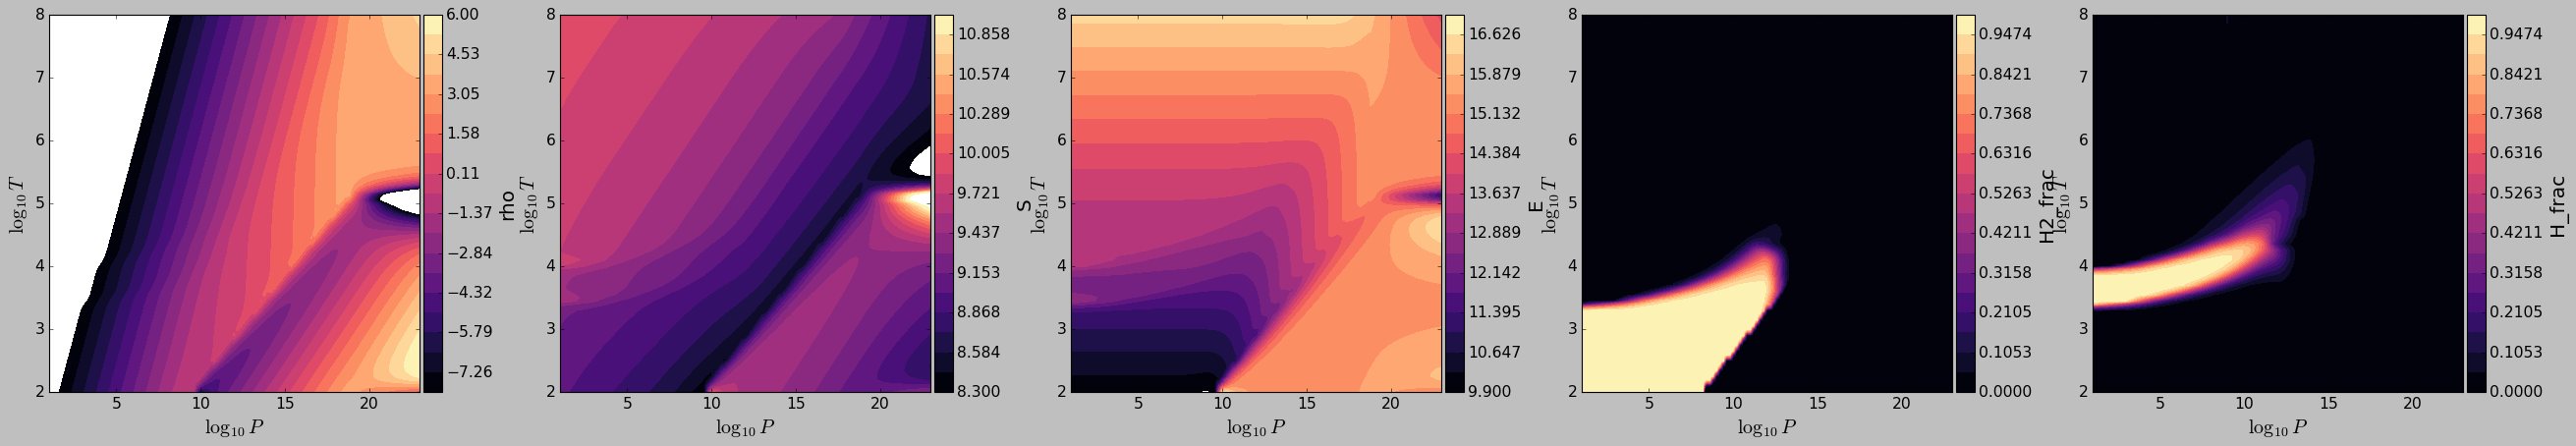

In [5]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=5, 
                                        xs=scvh_H_PT.log10Pgrid,
                                        ys=scvh_H_PT.log10Tgrid,
                                        zs=[scvh_H_PT.log10rhogrid,scvh_H_PT.log10Sgrid,scvh_H_PT.log10Egrid,scvh_H_PT.nm_grid,scvh_H_PT.na_grid],
                                        xlims=(1,23),
                                        ylims=(2,8),
                                        zlims=[(-8,6),(8.3,11),(9.9,17.),(0,1),(0,1)],
                                        levels=20,
                                        xlabels=r'$\log_{10}P$',
                                        ylabels=r'$\log_{10}T$',
                                        zlabels=['rho','S','E','H2_frac','H_frac'],
                                        cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                        species='H', plot_interpolation_lines=False, savename=None)
            

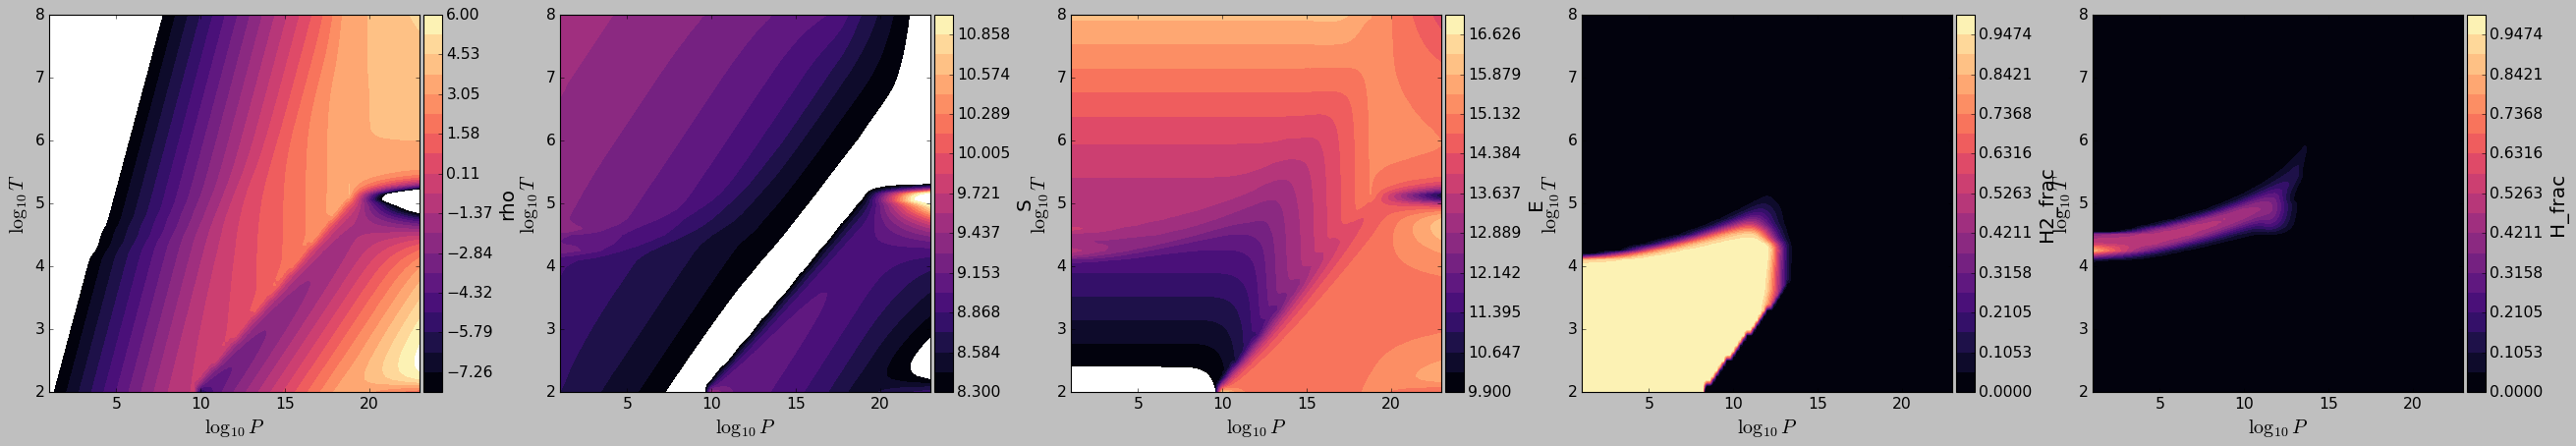

In [6]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=5, 
                                        xs=scvh_He_PT.log10Pgrid,
                                        ys=scvh_He_PT.log10Tgrid,
                                        zs=[scvh_He_PT.log10rhogrid,scvh_He_PT.log10Sgrid,scvh_He_PT.log10Egrid,scvh_He_PT.nm_grid,scvh_He_PT.na_grid],
                                        xlims=(1,23),
                                        ylims=(2,8),
                                        zlims=[(-8,6),(8.3,11),(9.9,17.),(0,1),(0,1)],
                                        levels=20,
                                        xlabels=r'$\log_{10}P$',
                                        ylabels=r'$\log_{10}T$',
                                        zlabels=['rho','S','E','H2_frac','H_frac'],
                                        cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                        species='H', plot_interpolation_lines=False, savename=None)
            

In [7]:
cd21_H_attr_list = dir(cd21_H)

cd21_H_attr_list_filtered = []
for i, li in enumerate(cd21_H_attr_list):
    if li[0] != "_":
        cd21_H_attr_list_filtered.append(li)
        
print(cd21_H_attr_list_filtered)

['Cp', 'Cv', 'X', 'Y', 'atomic_number', 'chiRho', 'chiT', 'compute_F_table', 'compute_partials', 'dE_drho_T', 'dE_drho_T_direct', 'dS_dT_rho', 'dS_dT_rho_direct', 'dS_drho_T', 'dS_drho_T_direct', 'dlE_dlrho_T', 'dlS_dlT_rho', 'dlS_dlrho_T', 'eosData', 'eta', 'filename', 'gamma1', 'gamma3', 'grad_ad', 'independent_arr_1', 'independent_arr_2', 'independent_var_1', 'independent_var_2', 'log10Egrid', 'log10Pgrid', 'log10Sgrid', 'log10Tgrid', 'log10Ugrid', 'log10rhogrid', 'log_free_e', 'mass_number', 'mu', 'units']


In [26]:
kB = 1.380649e-16 #erg/K
mH = 1.6605390689e-24 #g

def add_mixing_terms_CD21(H_PTtable, He_PTtable, Z_PTtable=None, X=0.725, Y=0.275):
    """
    Mix tables using additive volume law only, as I think is intended for CD21. 
    
    Assumes that all input tables are evaluated on the same P, T grid, and that
    the grid coordinates are
    
    Tarr=np.arange(2.,8.04,0.05) 
    Parr=np.arange(1.0,23.04,0.05)

    1/rho_mix = X/rho_H + Y/rho_He +
    S_mix = X*S_H + Y*S_He + X*Y*S_mix
    E_mix = X*E_H + Y*E_He
    """

    Z = 1. - (X + Y)

    shared_log10Tgrid = H_PTtable.log10Tgrid
    shared_log10Pgrid = H_PTtable.log10Pgrid

    mixed_table = meos.simple_table()
    mixed_table.X = X
    mixed_table.Y = Y
    mixed_table.log10Tgrid = shared_log10Tgrid
    mixed_table.log10Pgrid = shared_log10Pgrid

    mixed_log10rhogrid = np.zeros_like(shared_log10Tgrid)
    mixed_log10Sgrid = np.zeros_like(shared_log10Tgrid)
    mixed_log10Egrid = np.zeros_like(shared_log10Tgrid)

    Tarr = np.arange(2.,8.04,0.05)
    Parr = np.arange(1.0,23.04,0.05)

    for i, P in enumerate(Parr):
        Pround = np.round(P,2)

        for j, T in enumerate(Tarr):
            Tround = np.round(T,2)

            rho_H = 10**H_PTtable.log10rhogrid[i,j]
            rho_He = 10**He_PTtable.log10rhogrid[i,j]

            S_H = 10**H_PTtable.log10Sgrid[i,j]
            S_He = 10**He_PTtable.log10Sgrid[i,j]

            f_H2 = scvh_H_PT.nm_grid[i,j]
            f_H = scvh_H_PT.na_grid[i,j]

            f_He = scvh_He_PT.nm_grid[i,j]
            f_Heplus = scvh_He_PT.na_grid[i,j]

            mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
            mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus
        
            mu_tot = 1./((X/mu_H) + (Y/mu_He))

            f_X = X*(mu_tot/mu_H)
            f_Y = Y*(mu_tot/mu_He)

            S_id_mix = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y))/(mH * (f_X + 4.*f_Y)))
            
            E_H = 10**H_PTtable.log10Egrid[i,j]
            E_He = 10**He_PTtable.log10Egrid[i,j]

            if Z_PTtable is None:
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He)))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + S_id_mix)
                mixed_log10Egrid[i,j] = np.log10(X*E_H + Y*E_He)
                
            else:
                rho_Z = 10**Z_PTtable.log10rhogrid[i,j]
                S_Z = 10**Z_PTtable.log10Sgrid[i,j]
                E_Z = 10**Z_PTtable.log10Egrid[i,j]
                
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He) + (Z/rho_Z)))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + Z*S_Z)
                mixed_log10Egrid[i,j] = np.log10(X*E_H + Y*E_He + Z*E_Z)
    
    mixed_table.log10rhogrid = mixed_log10rhogrid
    mixed_table.log10Sgrid = mixed_log10Sgrid
    mixed_table.log10Egrid = mixed_log10Egrid
    
    return mixed_table
    


In [27]:
test_cd21_Y0275 = add_mixing_terms_CD21(H_PTtable=cd21_H, He_PTtable=cd21_He, Z_PTtable=None, X=0.725, Y=0.275)
print(test_cd21_Y0275.log10Sgrid[~np.isfinite(test_cd21_Y0275.log10Sgrid)])
print(test_cd21_Y0275.log10Egrid[~np.isfinite(test_cd21_Y0275.log10Egrid)])

# get rid of infs
test_cd21_Y0275.log10Sgrid[~np.isfinite(test_cd21_Y0275.log10Sgrid)] = np.max(test_cd21_Y0275.log10Sgrid[np.isfinite(test_cd21_Y0275.log10Sgrid)])
test_cd21_Y0275.log10Egrid[~np.isfinite(test_cd21_Y0275.log10Egrid)] = np.max(test_cd21_Y0275.log10Egrid[np.isfinite(test_cd21_Y0275.log10Egrid)])

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_73846/4184362920.py:46: RuntimeWarning: overflow encountered in scalar power
  S_H = 10**H_PTtable.log10Sgrid[i,j]
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_73846/4184362920.py:65: RuntimeWarning: overflow encountered in scalar power
  E_H = 10**H_PTtable.log10Egrid[i,j]
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_73846/4184362920.py:66: RuntimeWarning: overflow encountered in scalar power
  E_He = 10**He_PTtable.log10Egrid[i,j]


[inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf]
[inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf inf]


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_73846/4184362920.py:47: RuntimeWarning: overflow encountered in scalar power
  S_He = 10**He_PTtable.log10Sgrid[i,j]


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_73846/526892611.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


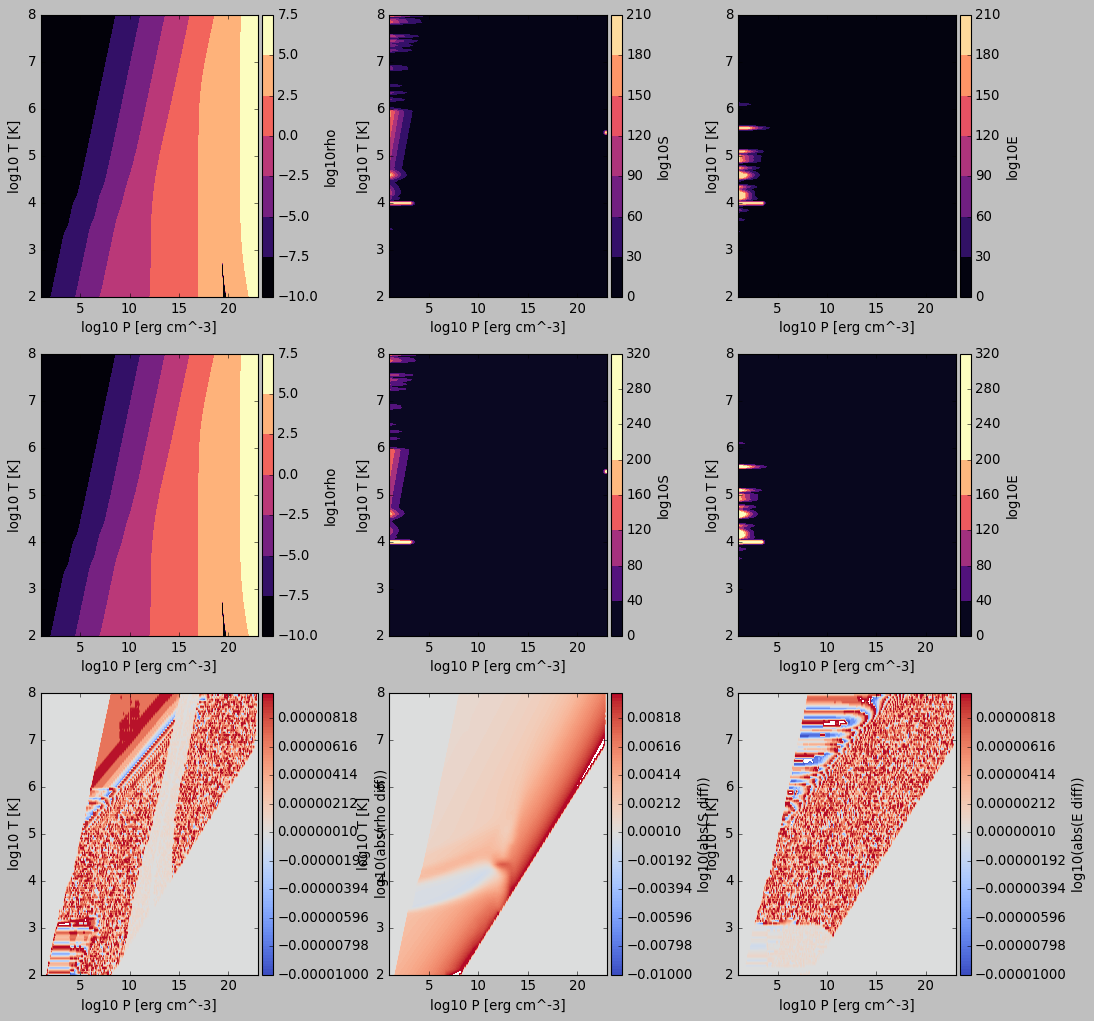

In [29]:
# plot differences between CD21-provided Y=0.275 table and the one I just calculated
rel_rho_diff = ((10**cd21_Y0275.log10rhogrid - 10**test_cd21_Y0275.log10rhogrid)/10**cd21_Y0275.log10rhogrid)
rel_S_diff = ((10**cd21_Y0275.log10Sgrid - 10**test_cd21_Y0275.log10Sgrid)/10**cd21_Y0275.log10Sgrid)
rel_E_diff = ((10**cd21_Y0275.log10Egrid - 10**test_cd21_Y0275.log10Egrid)/10**cd21_Y0275.log10Egrid)

phys_mask = (cd21_Y0275.log10rhogrid >= -8.) & (cd21_Y0275.log10rhogrid <= 6.)
rel_rho_diff[~phys_mask] = 0.
rel_S_diff[~phys_mask] = 0.
rel_E_diff[~phys_mask] = 0.

P_arr = np.linspace(1.,23.,100)
P_boundary = (1./3.)*P_arr - 0.9

P_boundary_grid = (1./3.)*cd21_Y0275.log10Pgrid - 0.7
boundary_mask = (cd21_Y0275.log10Tgrid < P_boundary_grid) 

rel_rho_diff[boundary_mask] = 0.
rel_S_diff[boundary_mask] = 0.
rel_E_diff[boundary_mask] = 0.


cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))
cmap.set_over('red')
cmap.set_under('black')
cmap.set_bad('grey')


fig, axes = plt.subplots(3,3,figsize=(15,15))
# CD21-provided Y=0.275 table
divider00 = make_axes_locatable(axes[0,0])
cax00 = divider00.append_axes('right', size='5%', pad=0.05)
cs00 = axes[0,0].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, cd21_Y0275.log10rhogrid, cmap='magma',vmin=-9,vmax=6.2)
fig.colorbar(cs00, cax=cax00, orientation='vertical',label='log10rho')

divider01 = make_axes_locatable(axes[0,1])
cax01 = divider01.append_axes('right', size='5%', pad=0.05)
cs01 = axes[0,1].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, cd21_Y0275.log10Sgrid, cmap='magma',vmin=7,vmax=210)
fig.colorbar(cs01, cax=cax01, orientation='vertical',label='log10S')

divider02 = make_axes_locatable(axes[0,2])
cax02 = divider02.append_axes('right', size='5%', pad=0.05)
cs02 = axes[0,2].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, cd21_Y0275.log10Egrid, cmap='magma',vmin=9,vmax=210)
fig.colorbar(cs02, cax=cax02, orientation='vertical',label='log10E')

# my Y=0.275 table
divider10 = make_axes_locatable(axes[1,0])
cax10 = divider10.append_axes('right', size='5%', pad=0.05)
cs10 = axes[1,0].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, test_cd21_Y0275.log10rhogrid, cmap='magma',vmin=-9,vmax=6.2)
fig.colorbar(cs10, cax=cax10, orientation='vertical',label='log10rho')

divider11 = make_axes_locatable(axes[1,1])
cax11 = divider11.append_axes('right', size='5%', pad=0.05)
cs11 = axes[1,1].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, test_cd21_Y0275.log10Sgrid, cmap='magma',vmin=7,vmax=210)
fig.colorbar(cs11, cax=cax11, orientation='vertical',label='log10S')

divider12 = make_axes_locatable(axes[1,2])
cax12 = divider12.append_axes('right', size='5%', pad=0.05)
cs12 = axes[1,2].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, test_cd21_Y0275.log10Egrid, cmap='magma',vmin=9,vmax=210)
fig.colorbar(cs12, cax=cax12, orientation='vertical',label='log10E')

# diff
divider20 = make_axes_locatable(axes[2,0])
cax20 = divider20.append_axes('right', size='5%', pad=0.05)
cs20 = axes[2,0].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, rel_rho_diff, cmap=cmap,levels=np.linspace(-0.00001,0.00001,100))
fig.colorbar(cs20, cax=cax20, orientation='vertical',label='log10(abs(rho diff))')

divider21 = make_axes_locatable(axes[2,1])
cax21 = divider21.append_axes('right', size='5%', pad=0.05)
cs21 = axes[2,1].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, rel_S_diff, cmap=cmap,levels=np.linspace(-0.01,0.01,100))
fig.colorbar(cs21, cax=cax21, orientation='vertical',label='log10(abs(S diff))')

divider22 = make_axes_locatable(axes[2,2])
cax22 = divider22.append_axes('right', size='5%', pad=0.05)
cs22 = axes[2,2].contourf(cd21_Y0275.log10Pgrid, cd21_Y0275.log10Tgrid, rel_E_diff, cmap=cmap,levels=np.linspace(-0.00001,0.00001,100))
fig.colorbar(cs22, cax=cax22, orientation='vertical',label='log10(abs(E diff))')

for ax in np.ravel(axes):
    ax.set_xlim(1,23.)
    ax.set_ylim(2.,8)
    ax.set_xlabel('log10 P [erg cm^-3]')
    ax.set_ylabel('log10 T [K]')
    
plt.subplots_adjust(wspace=0.5)
plt.show()